# 팀 시너지 모형 시연 노트북

Brave, Butters & Roberts (2019) *Uncovering the sources of team synergy* 구현(`team_synergy` 패키지)을 **합성 데이터**로 단계별로 시연한다.
합성 패널은 참값(ρ, λ, c, tp)을 알고 있으므로, 추정 결과가 참값을 얼마나 복원하는지 직접 확인할 수 있다.

| 절 | 내용 | 논문 |
|---|---|---|
| 1 | 합성 패널 생성 | 3–7절 검증용 |
| 2 | 팀 승수 회귀와 선수 잔차 | 식 1, 4, 7 |
| 3 | 팀메이트 네트워크와 SAR 추정 (ρ) | 식 8 |
| 4 | 2요인 모형 (λ: 조직문화) | 5절, 부록 7.2 |
| 5 | WAR−, WAR+, pcWAR, tcWAR 분해 | 식 10–13 |
| 6 | 재귀 추정 | 7절 |
| 7 | 8절 분석 (표·그림) | 8절 |
| 8 | 실데이터 (원자료가 있을 때) | — |

> 합성 데이터는 MLB에 보정되지 않았다. 여기서의 수치는 코드가 올바르게 동작하는지 보는 용도이며, 논문 수치의 재현은 실데이터로 판정해야 한다.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from team_synergy.config import load_config
from team_synergy.synthetic import make_synthetic_panel
from team_synergy.model.team_reg import fit_team_regression
from team_synergy.model.residuals import player_residuals
from team_synergy.model.network import build_blocks
from team_synergy.model.sar import fit_sar
from team_synergy.model.factor_als import fit_factor_als
from team_synergy.model.factor_prob import fit_factor_prob
from team_synergy.model.recursive import estimate_window, run_recursive

SEED = 0
cfg = load_config()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)

## 1. 합성 패널 생성

`make_synthetic_panel`은 구단 문화 λ, 선수-시즌 요인 (c, tp), 팀메이트 외부효과 ρ를 심어 stint 단위 패널을 만든다.
시연이 빠르도록 12개 팀 × 6시즌 × 로스터 30명의 작은 패널을 쓴다(실제 설정은 30팀 × 19시즌).
난수는 시드로 고정한다.

In [2]:
panel, truth = make_synthetic_panel(n_teams=12, n_seasons=6, roster=30, rho=0.3, seed=SEED)
print(f"stints={len(panel)}, team-seasons={panel.groupby(['franch_id','season']).ngroups}")
print(f"true rho={truth['rho']}, alpha={truth['alpha']}, beta={truth['beta']}")
panel[["player_id", "season", "franch_id", "group", "war", "weight", "team_wins"]].head()

stints=2417, team-seasons=72
true rho=0.3, alpha=48.0, beta=1.0


,player_id,season,franch_id,group,war,weight,team_wins
0,p00000,2000,T00,pit,1.003,0.014,76.88
1,p00001,2000,T00,bat,1.248,0.011,76.88
2,p00002,2000,T00,bat,0.232,0.010,76.88
3,p00003,2000,T00,bat,-0.005,0.026,76.88
4,p00004,2000,T00,pit,0.113,0.009,76.88


## 2. 팀 승수 회귀와 선수 잔차 (식 1, 4, 7)

팀 승수를 팀 WAR 합에 회귀하고(식 1: $W = \alpha + \beta \sum WAR + \varepsilon$), 팀 잔차를 출장 가중치 $\eta\tau$로 선수 stint에 배분해 선수 생산성 잔차 $y$를 만든다.
합성 데이터에서는 참값 $\alpha=48,\ \beta=1$ 이고 $y$의 참값도 알고 있다.

In [3]:
reg = fit_team_regression(panel, beta_mode="estimated")
print(f"alpha={reg.alpha:.2f} (true {truth['alpha']}),  beta={reg.beta:.3f} (true {truth['beta']}),  R2={reg.r2:.3f}")

res_df = player_residuals(panel, reg, sign_convention="consistent")
y = res_df["y"].to_numpy()
print(f"corr(y_hat, y_true) = {np.corrcoef(y, truth['y_true'])[0, 1]:.4f}")

alpha=46.62 (true 48.0),  beta=1.047 (true 1.0),  R2=0.647
corr(y_hat, y_true) = 0.9998


## 3. 팀메이트 네트워크와 SAR 추정 (식 8)

같은 팀-시즌에서 함께 뛴 선수들의 인접 행렬 $A$를 만들고, 공간 자기회귀(SAR) 모형 $y = \rho A y + v$ 를 집중우도로 추정한다.
아래 그림은 ρ에 대한 집중로그우도 프로파일이다.

이 시연 패널은 작아서 ρ̂가 참값(0.3)보다 낮게 나올 수 있다. 또한 집중우도 곡률 기반 표준오차는 과소추정되는 경향이 있어(CLAUDE.md 오픈 이슈), 실제 추론은 부트스트랩으로 한다.

rho_hat=0.149 (true 0.3), SE=0.067, at_bound=False


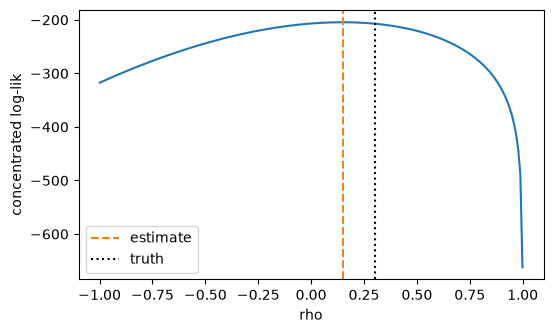

In [4]:
blocks = build_blocks(panel, history=cfg["history"])
sar = fit_sar(y, blocks)
print(f"rho_hat={sar.rho:.3f} (true {truth['rho']}), SE={sar.se:.3f}, at_bound={sar.at_bound}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(sar.profile.iloc[:, 0], sar.profile.iloc[:, 1])
ax.axvline(sar.rho, color="C1", ls="--", label="estimate")
ax.axvline(truth["rho"], color="k", ls=":", label="truth")
ax.set_xlabel("rho"); ax.set_ylabel("concentrated log-lik"); ax.legend()
plt.show()

## 4. 2요인 모형: 조직문화 λ (5절)

SAR 이후의 구조 충격 $v$를 $g = c + tp \cdot \lambda_n$ 으로 분해한다.
- $c$: 선수 고유 성분(character), $tp$: 선수가 구단 문화에 반응하는 정도, $\lambda_n$: 구단 $n$의 조직문화
- A안은 ALS(부록 7.2), B안은 확률적 요인모형(EM)이다.

λ는 부호·척도의 모호함이 있으므로 참값과의 **상관의 절댓값**으로 비교한다. (CLAUDE.md 오픈 이슈: A안 λ는 관측 팀 수가 적으면 시작값에 의존)

In [5]:
w = panel["weight"].to_numpy()
als = fit_factor_als(panel, sar.v, w, scale="tp_var")
prob = fit_factor_prob(panel, sar.v, w, scale="tp_var")

lam_true = truth["lam"]
rows = []
for name, f in [("A: ALS", als), ("B: prob", prob)]:
    r = np.corrcoef(f.lam.reindex(lam_true.index), lam_true)[0, 1]
    rows.append(dict(method=name, iters=f.n_iter, converged=f.converged,
                     explained_share=f.explained_share, abs_corr_lambda=abs(r)))
pd.DataFrame(rows).set_index("method")

,iters,converged,explained_share,abs_corr_lambda
method,,,,
A: ALS,12,True,1.000,0.788
B: prob,544,True,0.979,0.997


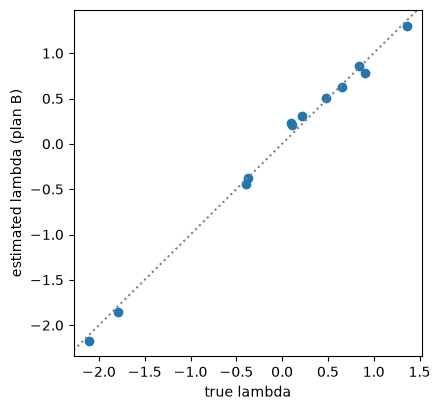

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
lam_b = prob.lam.reindex(lam_true.index)
sign = np.sign(np.corrcoef(lam_b, lam_true)[0, 1])  # resolve sign ambiguity for plotting
ax.scatter(lam_true, sign * lam_b)
ax.axline((0, 0), slope=1, color="gray", ls=":")
ax.set_xlabel("true lambda"); ax.set_ylabel("estimated lambda (plan B)")
plt.show()

## 5. WAR−, WAR+, pcWAR, tcWAR 분해 (식 10–13)

`estimate_window`가 2–4절을 한 번에 실행하고 분해까지 마친다. 정의:

- **WAR−**: 동료 영향을 제거한 선수 가치, **WAR+**: 동료 영향을 포함한 값
- **pcWAR = WAR+ − WAR**: 선수 보완효과 (팀 안에서 합 = 0)
- **tcWAR**: 팀 전체 네트워크 효과

여기서 항등식(ΣWAR+ = ΣWAR, ΣpcWAR = 0)과 논문 주장 방향의 진단 두 가지도 확인한다.

In [7]:
win = estimate_window(panel, cfg)
teams = win.teams
print("sum(war_plus - war) per team-season, max abs:", (teams["war_plus"] - teams["war"]).abs().max().round(8))
print("sum(pc_war) per team-season, max abs:       ", teams["pc_war"].abs().max().round(8))

d = win.diagnostics
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in d.items()})
win.stints[["player_id", "season", "franch_id", "war", "war_minus", "war_plus", "pc_war"]].head()

sum(war_plus - war) per team-season, max abs: 0.0
sum(pc_war) per team-season, max abs:        0.0
{'ratio': 0.854, 'corr_tc_eps': 0.958, 'sd_eps_war': 7.997, 'sd_eps_war_minus': 6.828, 'beta': 1.047}


,player_id,season,franch_id,war,war_minus,war_plus,pc_war
0,p00000,2000,T00,1.003,0.997,1.082,0.078
1,p00001,2000,T00,1.248,1.240,1.338,0.089
2,p00002,2000,T00,0.232,0.221,0.216,-0.017
3,p00003,2000,T00,-0.005,-0.017,-0.130,-0.125
4,p00004,2000,T00,0.113,0.103,0.085,-0.028


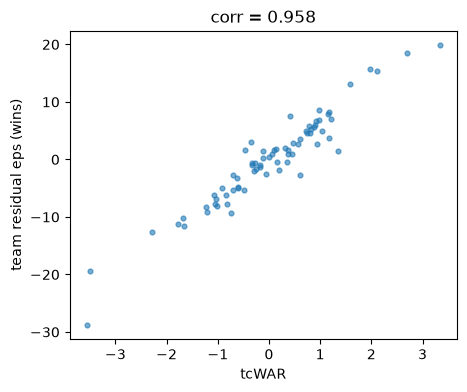

,player_id,season,war,pc_war,pc_war_char,pc_war_team
1289,p00271,2005,5.805,1.644,0.044,1.599
1356,p00288,2001,5.728,1.095,0.030,1.066
1298,p00274,2003,4.619,1.082,0.029,1.053
922,p00197,2000,2.984,-1.200,-0.123,-1.076
1292,p00273,2000,-3.218,-1.198,-0.034,-1.164
1406,p00299,2001,-4.476,-1.173,-0.032,-1.141


In [8]:
# Diagnostic 2: tcWAR should be positively correlated with the team residual eps
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(teams["tc_war"], teams["eps"], s=12, alpha=0.6)
ax.set_xlabel("tcWAR"); ax.set_ylabel("team residual eps (wins)")
ax.set_title(f"corr = {teams['tc_war'].corr(teams['eps']):.3f}")
plt.show()

# Top / bottom players by pcWAR in the final window
ps = win.player_seasons.reset_index()
pd.concat([ps.nlargest(3, "pc_war"), ps.nsmallest(3, "pc_war")])[["player_id", "season", "war", "pc_war", "pc_war_char", "pc_war_team"]]

## 6. 재귀 추정 (7절)

논문은 시점 $T$까지의 표본으로 모형을 반복 추정(재귀 윈도)하여 시간이 지남에 따라 추정값이 안정되는지 본다.
`run_recursive`는 각 윈도 $[start, T]$를 추정하고 요약을 낸다. 아래는 마지막 3개 윈도만 돌린다.

In [9]:
rec = run_recursive(panel, cfg, min_end=int(panel["season"].max()) - 2)
cols = ["window_end", "n_stints", "alpha", "beta", "rho", "explained_share", "ratio", "corr_tc_eps"]
rec["window_summary"][cols]

,window_end,n_stints,alpha,beta,rho,explained_share,ratio,corr_tc_eps
0,2003,1626,49.905,0.934,0.185,1.0,0.797,0.969
1,2004,2022,48.429,1.000,0.120,1.0,0.877,0.966
2,2005,2417,46.617,1.047,0.149,1.0,0.854,0.958


## 7. 8절 분석: 표와 그림

`synthetic_inputs`가 합성 패널 → 재귀 추정 → 분석 입력을 만들고, `run_all`이 8절 분석 모듈을 실행한다.
부트스트랩 반복 수와 윈도 수를 줄여 빠르게 돌린다(전체는 `synergy analyze --synthetic`, 약 3분).
각 모듈은 논문 기대 결과와 비교하는 `checks`를 반환한다.

In [10]:
from team_synergy.analysis.inputs import synthetic_inputs
from team_synergy.analysis.runner import run_all
from team_synergy.viz import figures as F

inputs = synthetic_inputs(seed=SEED, n_seasons=8, n_teams=12, roster=30, cfg=cfg)
results = run_all(inputs, n_boot=30, seed=SEED, only=["table1", "org_culture", "tc_persistence"])
{k: f"{len(v.tables)} tables, {len(v.checks)} checks" for k, v in results.items()}

{'table1': '4 tables, 5 checks',
 'org_culture': '2 tables, 2 checks',
 'tc_persistence': '4 tables, 4 checks'}

In [11]:
# Table 1: team win regressions, WAR vs WAR-
t1 = results["table1"].tables["table1"]
t1[["spec", "alpha", "beta", "r2", "pseudo_r2", "paper_beta", "paper_r2"]]

,spec,alpha,beta,r2,pseudo_r2,paper_beta,paper_r2
0,(1) sum WAR,46.391,1.035,0.563,0.550,0.996,0.799
1,(2) sum WAR-,42.553,1.146,0.690,0.671,1.030,0.887


In [12]:
results["table1"].checks_frame()

,item,value,expected,passed
0,beta (spec 1) within 2 SE of 1,1.035 (SE 0.097),"beta 0.996 (fWAR), approximately 1",True
1,alpha (spec 1) < 50,46.39,"alpha 47.7, 'just less than 50'",True
2,R2 rises from WAR to WAR-,0.563 -> 0.690,0.799 -> 0.887 (fWAR),True
3,pseudo R2 rises from WAR to WAR-,0.550 -> 0.671,0.789 -> 0.873 (fWAR),True
4,sd(resid WAR-) / sd(resid WAR) < 1,"0.842 (BCa95 0.823, 0.860); sd 8.30 -> 6.99",sd about 5 -> about 4 wins; about 40% less une...,True


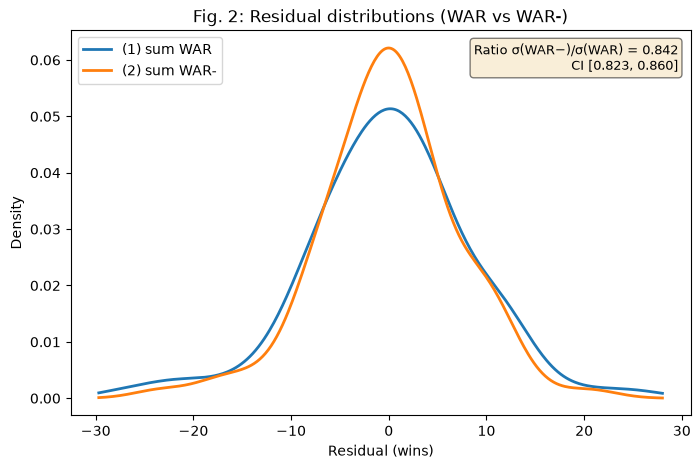

In [13]:
fig = F.fig2(results["table1"])
plt.show()

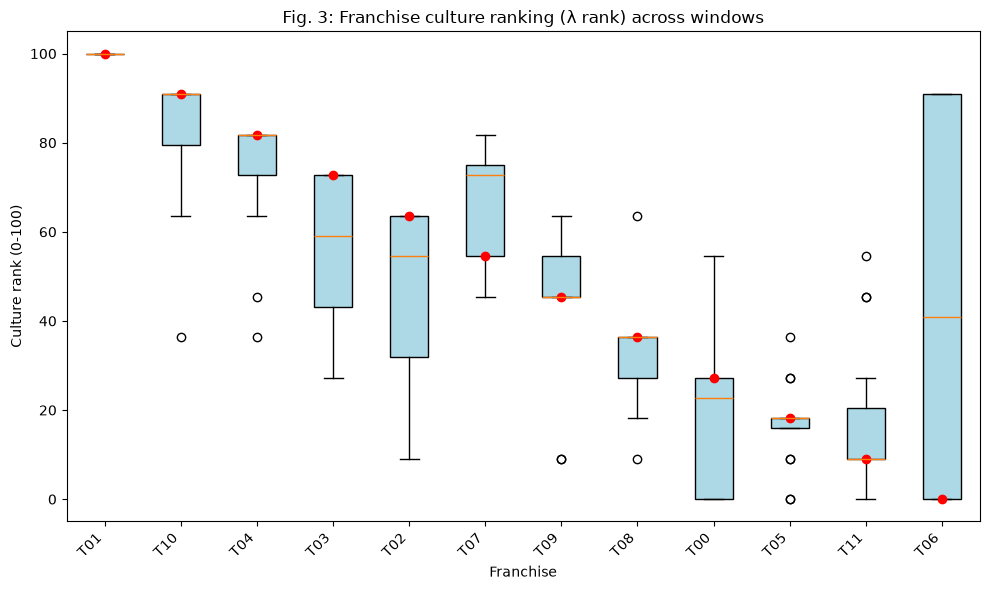

In [14]:
fig = F.fig3(results["org_culture"])
plt.show()

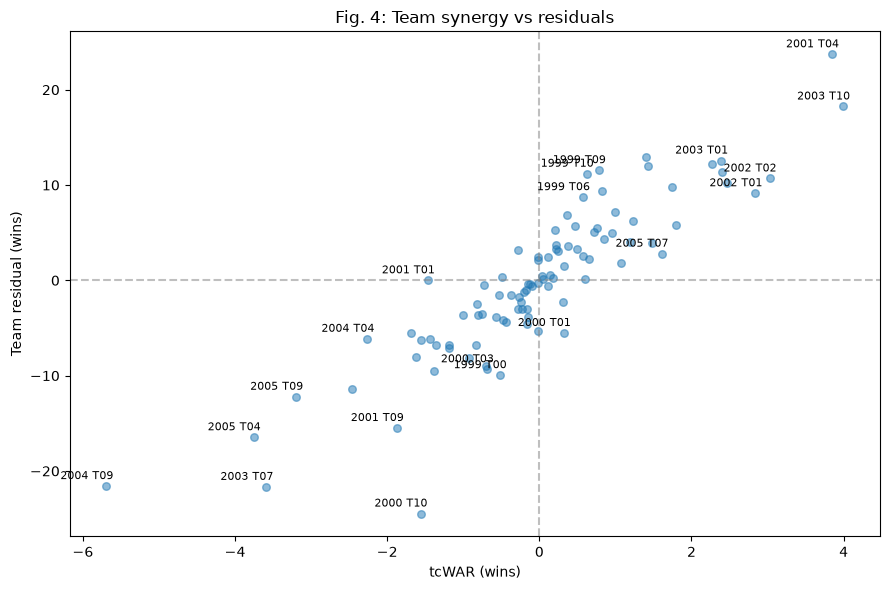

In [15]:
fig = F.fig4(results["tc_persistence"])
plt.show()

나머지 분석(표 3 PECOTA, 그림 6–8 선수 평가, 표 4 지속성, 표 5 연봉, Intangibles 등)은 `synergy analyze`로 한 번에 돌려 `outputs/<data>/REPORT.md`에서 볼 수 있다.
합성 데이터에서 일부 점검이 실패하는 것은 생성 과정에 선수 요인의 시즌 간 지속성이 없기 때문이며, 실데이터로 판정해야 한다.

## 8. 실데이터

`synergy fetch` → `synergy build --war fwar` → `synergy estimate --war fwar` 를 마치면 같은 분석을 실데이터에 적용할 수 있다.
아래 셀은 가공된 입력이 있을 때만 실행되고, 없으면 안내만 출력한다.

In [16]:
from pathlib import Path
from team_synergy.analysis.inputs import load_inputs

proc = Path("../data/processed/fwar")
if (proc / "metrics_full.parquet").exists():
    real = load_inputs(proc, "fwar", cfg=cfg)
    real_res = run_all(real, n_boot=100, seed=SEED, only=["table1"])
    display(real_res["table1"].tables["table1"][["spec", "alpha", "beta", "r2", "pseudo_r2"]])
else:
    print("실데이터 가공 결과 없음: `synergy build --war fwar && synergy estimate --war fwar` 를 먼저 실행하세요.")

실데이터 가공 결과 없음: `synergy build --war fwar && synergy estimate --war fwar` 를 먼저 실행하세요.
